Note: you may need to restart the kernel to use updated packages.
Rocket Telemetry Data Summary:
First few rows with elapsed time:
                 TIME  elapsed_seconds  Alt AGL (ft)
0 1900-01-01 14:56:04              0.0        -7.288
1 1900-01-01 14:56:05              1.0        -7.374
2 1900-01-01 14:56:06              2.0        -7.508
3 1900-01-01 14:56:07              3.0        -7.567
4 1900-01-01 14:56:08              4.0        -7.823

Flight Analysis:
Apogee: 38472.2 ft at 87.0 seconds
Saved altitude plot: plots/altitude_vs_time.png and .pdf


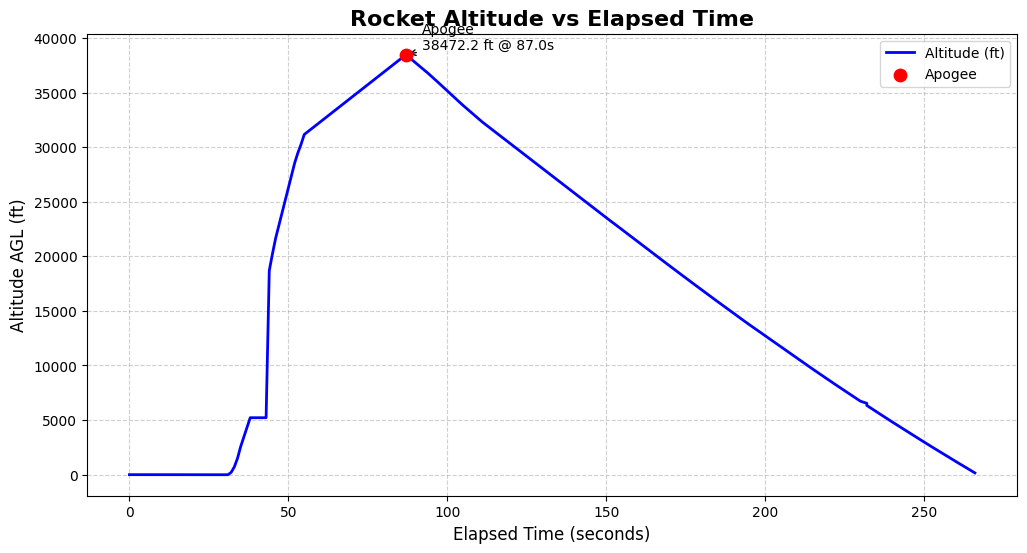

In [2]:
# Rocket Telemetry Data Analysis

%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create plots directory for saving high-resolution images
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' folder for saving plot images")

df = pd.read_csv("Trimmed Aurora Telemetry Data.csv")

# Convert TIME column to datetime format for proper time calculations
df['TIME'] = pd.to_datetime(df['TIME'], format='%I:%M:%S %p')

# Calculate elapsed time in seconds from the first timestamp
start_time = df['TIME'].iloc[0]
df['elapsed_seconds'] = (df['TIME'] - start_time).dt.total_seconds()

# Convert altitude to numeric values (handles any string data)
df['Alt AGL (ft)'] = pd.to_numeric(df['Alt AGL (ft)'], errors='coerce')

print("Rocket Telemetry Data Summary:")
print("=" * 40)
print("First few rows with elapsed time:")
print(df[['TIME', 'elapsed_seconds', 'Alt AGL (ft)']].head())

# Find apogee (maximum altitude point)
apogee_idx = df['Alt AGL (ft)'].idxmax()   # row where altitude is max
apogee_time = df.loc[apogee_idx, 'elapsed_seconds']  # time at apogee
apogee_alt  = df.loc[apogee_idx, 'Alt AGL (ft)']

print(f"\nFlight Analysis:")
print(f"Apogee: {apogee_alt:.1f} ft at {apogee_time:.1f} seconds")

# Create altitude vs time plot
plt.figure(figsize=(12, 6)) 
plt.plot(df['elapsed_seconds'], df['Alt AGL (ft)'], 'b-', linewidth=2, label='Altitude (ft)')

plt.scatter([apogee_time], [apogee_alt], color='red', s=80, zorder=5, label='Apogee')

plt.annotate(f'Apogee\n{apogee_alt:.1f} ft @ {apogee_time:.1f}s', 
             xy=(apogee_time, apogee_alt), 
             xytext=(apogee_time + 5, apogee_alt + 500), # offset label
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=10, color='black')

plt.title('Rocket Altitude vs Elapsed Time', fontsize=16, fontweight='bold')
plt.xlabel('Elapsed Time (seconds)', fontsize=12)
plt.ylabel('Altitude AGL (ft)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save plots in multiple formats for different uses
plt.savefig('plots/altitude_vs_time.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('plots/altitude_vs_time.pdf', bbox_inches='tight', facecolor='white')
print(f"Saved altitude plot: plots/altitude_vs_time.png and .pdf")

plt.show()

In [5]:
# Check available columns in the dataframe
print("Available columns in the dataframe:")
print(df.columns.tolist())

Available columns in the dataframe:
['TIME', 'TRACKER Lat', 'TRACKER Lon', 'Alt AGL (ft)', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Needed for google earth ->', 'Unnamed: 13', 'Unnamed: 14', 'TRACKER Alt asl', 'elapsed_seconds']



IMPROVED GPS ANALYSIS WITH OUTLIER FILTERING
Filtered out GPS outlier at 44.0s: 3832.1 ft/s
Original data points: 100
Filtered data points: 97
Outliers removed: 3

Filtered GPS Analysis Results:
Maximum lateral velocity: 461.5 ft/s
Average lateral velocity: 56.2 ft/s
Maximum distance from launch: 18068.9 feet

Apogee marker for velocity plot:
Closest GPS point to apogee (87.0s): 87.0s
Lateral velocity at apogee: 257.9 ft/s
Saved filtered GPS analysis plots: plots/gps_trajectory_analysis_filtered.png and .pdf
Saved filtered GPS analysis plots: plots/gps_trajectory_analysis_filtered.png and .pdf


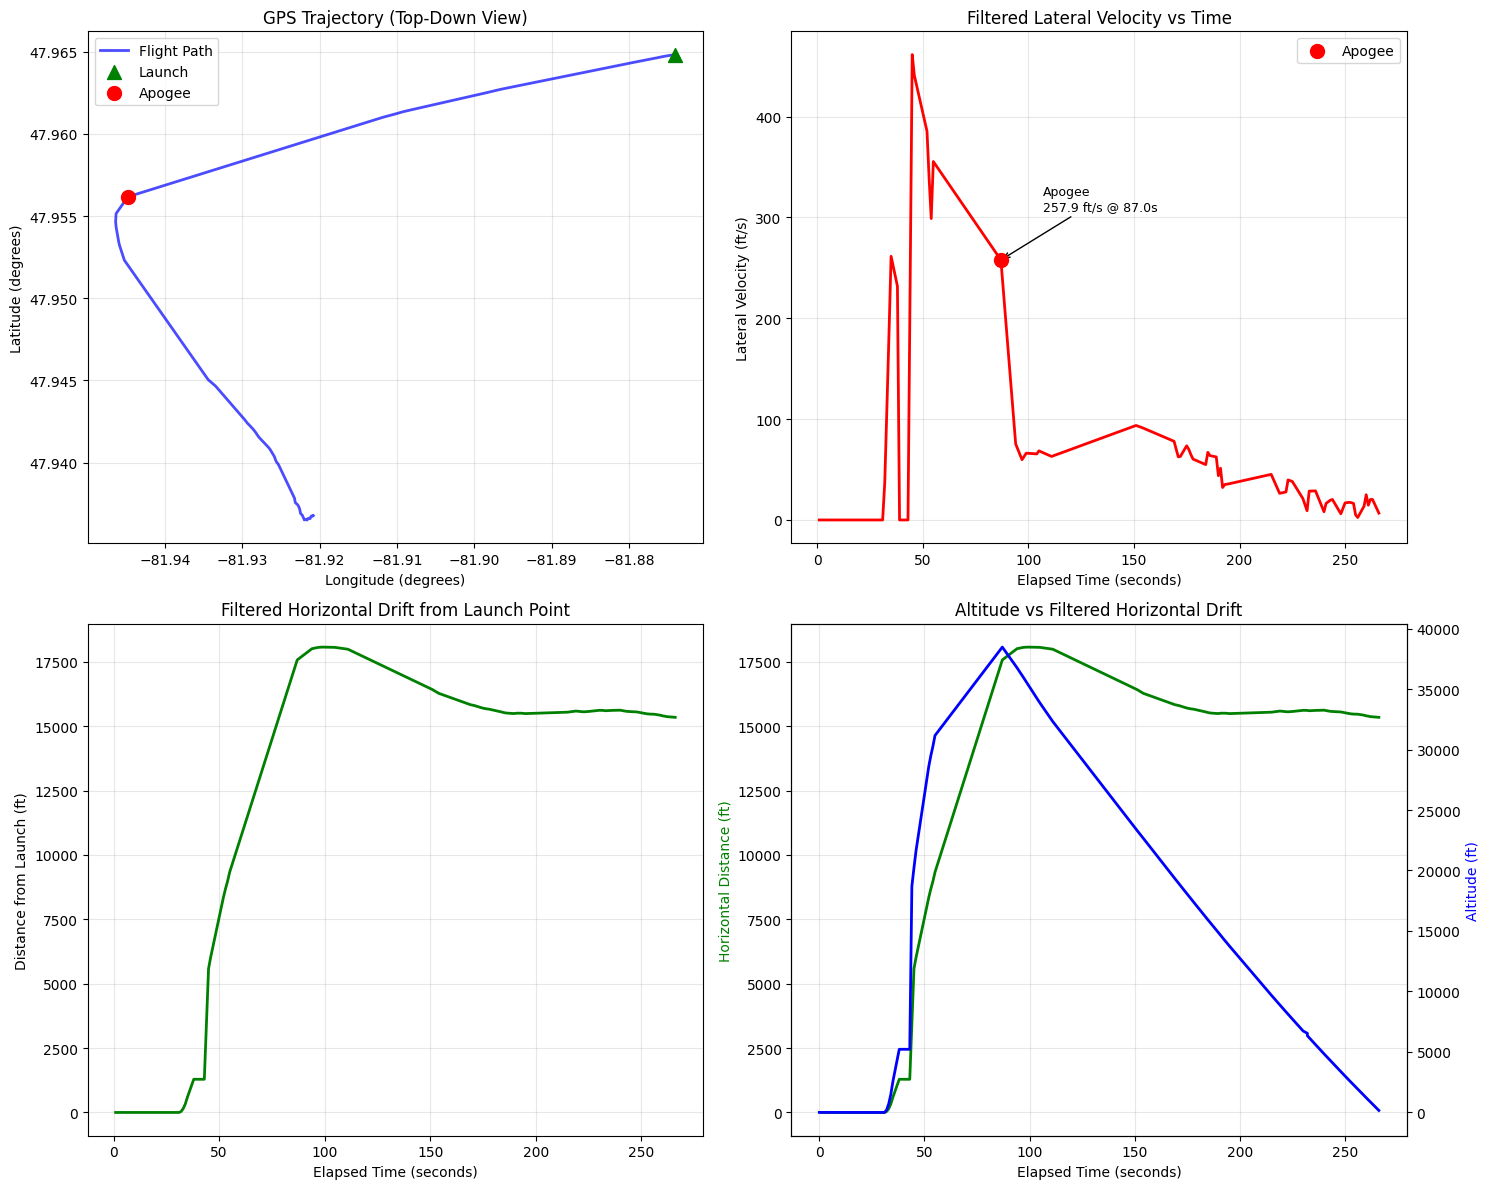

In [6]:
# Improved GPS Analysis with Outlier Filtering
print("\nIMPROVED GPS ANALYSIS WITH OUTLIER FILTERING")
print("=" * 55)

# Haversine function to calculate distance between two GPS coordinates
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in feet
    """
    from math import radians, cos, sin, asin, sqrt
    
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Radius of earth in feet (3959 miles * 5280 ft/mile)
    r = 3959 * 5280
    return c * r

# Define column names for GPS coordinates
latitude_col = 'TRACKER Lat'
longitude_col = 'TRACKER Lon'

# Extract GPS data from the main dataframe
gps_data = df[[latitude_col, longitude_col, 'elapsed_seconds']].copy()

# Store launch point coordinates
launch_lat = gps_data.iloc[0][latitude_col]
launch_lon = gps_data.iloc[0][longitude_col]

# Define reasonable velocity threshold
MAX_REASONABLE_VELOCITY = 1000  # ft/s

# Recalculate with outlier filtering
filtered_distances = []
filtered_velocities = []
filtered_indices = []

for i in range(1, len(gps_data)):
    # Calculate distance and velocity
    dist = haversine_distance(
        gps_data.iloc[i-1][latitude_col], gps_data.iloc[i-1][longitude_col],
        gps_data.iloc[i][latitude_col], gps_data.iloc[i][longitude_col]
    )
    
    time_diff = gps_data.iloc[i]['elapsed_seconds'] - gps_data.iloc[i-1]['elapsed_seconds']
    
    if time_diff > 0:
        velocity = dist / time_diff
        
        # Filter out unrealistic velocities
        if velocity <= MAX_REASONABLE_VELOCITY:
            filtered_distances.append(dist)
            filtered_velocities.append(velocity)
            filtered_indices.append(i)
        else:
            print(f"Filtered out GPS outlier at {gps_data.iloc[i]['elapsed_seconds']:.1f}s: {velocity:.1f} ft/s")

# Create filtered dataset
gps_filtered = gps_data.iloc[filtered_indices].copy()
gps_filtered['lateral_distance_ft'] = filtered_distances
gps_filtered['lateral_velocity_fts'] = filtered_velocities

# Recalculate distance from launch for filtered data
gps_filtered['distance_from_launch_ft'] = [
    haversine_distance(launch_lat, launch_lon, row[latitude_col], row[longitude_col])
    for _, row in gps_filtered.iterrows()
]

print(f"Original data points: {len(gps_data)}")
print(f"Filtered data points: {len(gps_filtered)}")
print(f"Outliers removed: {len(gps_data) - len(gps_filtered)}")

print(f"\nFiltered GPS Analysis Results:")
print(f"Maximum lateral velocity: {max(filtered_velocities):.1f} ft/s")
print(f"Average lateral velocity: {np.mean(filtered_velocities):.1f} ft/s")
print(f"Maximum distance from launch: {max(gps_filtered['distance_from_launch_ft']):.1f} feet")

# Find the GPS point closest to apogee time for marking on velocity plot
apogee_gps_idx = (gps_filtered['elapsed_seconds'] - apogee_time).abs().idxmin()
apogee_gps_time = gps_filtered.loc[apogee_gps_idx, 'elapsed_seconds']
apogee_gps_velocity = gps_filtered.loc[apogee_gps_idx, 'lateral_velocity_fts']

print(f"\nApogee marker for velocity plot:")
print(f"Closest GPS point to apogee ({apogee_time:.1f}s): {apogee_gps_time:.1f}s")
print(f"Lateral velocity at apogee: {apogee_gps_velocity:.1f} ft/s")

# Create new plot with filtered data
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: GPS Trajectory (Bird's Eye View)
ax1.plot(df[longitude_col], df[latitude_col], 'b-', linewidth=2, alpha=0.7, label='Flight Path')
ax1.scatter(df.iloc[0][longitude_col], df.iloc[0][latitude_col], 
           color='green', s=100, marker='^', label='Launch', zorder=5)
ax1.scatter(df.iloc[apogee_idx][longitude_col], df.iloc[apogee_idx][latitude_col], 
           color='red', s=100, marker='o', label='Apogee', zorder=5)
ax1.set_xlabel('Longitude (degrees)')
ax1.set_ylabel('Latitude (degrees)')
ax1.set_title('GPS Trajectory (Top-Down View)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Filtered Lateral Velocity Over Time with Apogee Marker
ax2.plot(gps_filtered['elapsed_seconds'], gps_filtered['lateral_velocity_fts'], 'r-', linewidth=2)
ax2.scatter([apogee_gps_time], [apogee_gps_velocity], color='red', s=100, marker='o', zorder=5, label='Apogee')
ax2.annotate(f'Apogee\n{apogee_gps_velocity:.1f} ft/s @ {apogee_gps_time:.1f}s', 
             xy=(apogee_gps_time, apogee_gps_velocity), 
             xytext=(apogee_gps_time + 20, apogee_gps_velocity + 50),
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=9, color='black')
ax2.set_xlabel('Elapsed Time (seconds)')
ax2.set_ylabel('Lateral Velocity (ft/s)')
ax2.set_title('Filtered Lateral Velocity vs Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Filtered Horizontal Drift from Launch
ax3.plot(gps_filtered['elapsed_seconds'], gps_filtered['distance_from_launch_ft'], 'g-', linewidth=2)
ax3.set_xlabel('Elapsed Time (seconds)')
ax3.set_ylabel('Distance from Launch (ft)')
ax3.set_title('Filtered Horizontal Drift from Launch Point')
ax3.grid(True, alpha=0.3)

# Plot 4: Combined Altitude and Horizontal Movement (filtered)
ax4.plot(gps_filtered['elapsed_seconds'], gps_filtered['distance_from_launch_ft'], 
        'g-', linewidth=2, label='Horizontal Distance')
ax4_twin = ax4.twinx()
ax4_twin.plot(df['elapsed_seconds'], df['Alt AGL (ft)'], 'b-', linewidth=2, label='Altitude')
ax4.set_xlabel('Elapsed Time (seconds)')
ax4.set_ylabel('Horizontal Distance (ft)', color='g')
ax4_twin.set_ylabel('Altitude (ft)', color='b')
ax4.set_title('Altitude vs Filtered Horizontal Drift')
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Save filtered analysis plots
plt.savefig('plots/gps_trajectory_analysis_filtered.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('plots/gps_trajectory_analysis_filtered.pdf', bbox_inches='tight', facecolor='white')
print(f"Saved filtered GPS analysis plots: plots/gps_trajectory_analysis_filtered.png and .pdf")

plt.show()


In [7]:
# Plot File Management and Summary
print("PLOT FILE MANAGEMENT")
print("=" * 50)

import os
import glob

def manage_plot_files():
    """
    Manage plot files in the plots directory.
    Removes outdated files and provides summary of current plots.
    """
    plot_dir = 'plots'
    
    if not os.path.exists(plot_dir):
        print(f"No '{plot_dir}' directory found")
        return
    
    # Define outdated files to remove (old unfiltered GPS plots)
    outdated_patterns = [
        'gps_trajectory_analysis.png',
        'gps_trajectory_analysis.pdf'
    ]
    
    # Remove outdated files
    removed_files = []
    for pattern in outdated_patterns:
        file_path = os.path.join(plot_dir, pattern)
        if os.path.exists(file_path):
            os.remove(file_path)
            removed_files.append(pattern)
    
    if removed_files:
        print(f"Removed outdated files:")
        for file in removed_files:
            print(f"    - {file}")
        print()
    
    # Get current plot files
    plot_extensions = ['.png', '.pdf', '.jpg', '.svg']
    current_plots = []
    
    for ext in plot_extensions:
        pattern = os.path.join(plot_dir, f'*{ext}')
        current_plots.extend(glob.glob(pattern))
    
    # Display current plots
    if current_plots:
        print(f"Current plot files ({len(current_plots)} total):")
        for plot_path in sorted(current_plots):
            filename = os.path.basename(plot_path)
            file_size = os.path.getsize(plot_path) / 1024  # Size in KB
            
            # Categorize plots
            if 'altitude' in filename:
                category = "Altitude Analysis"
            elif 'filtered' in filename:
                category = "Filtered GPS Analysis"
            else:
                category = "Other"
            
            print(f"    {filename:<35} ({file_size:6.1f} KB) - {category}")
    else:
        print("No plot files found")
    
    return len(current_plots)

# Run the plot management function
total_plots = manage_plot_files()

print(f"\nPlot Management Complete")
print(f"Total active plot files: {total_plots}")

# Expected final plots for this analysis:
expected_plots = [
    "altitude_vs_time.png",
    "altitude_vs_time.pdf", 
    "gps_trajectory_analysis_filtered.png",
    "gps_trajectory_analysis_filtered.pdf"
]

print(f"Expected plots for rocket telemetry analysis: {len(expected_plots)}")
for plot in expected_plots:
    status = "✓" if os.path.exists(f'plots/{plot}') else "✗"
    print(f"    {status} {plot}")

PLOT FILE MANAGEMENT
Current plot files (4 total):
    altitude_vs_time.pdf                (  22.3 KB) - Altitude Analysis
    altitude_vs_time.png                ( 181.0 KB) - Altitude Analysis
    gps_trajectory_analysis_filtered.pdf (  25.7 KB) - Filtered GPS Analysis
    gps_trajectory_analysis_filtered.png ( 539.8 KB) - Filtered GPS Analysis

Plot Management Complete
Total active plot files: 4
Expected plots for rocket telemetry analysis: 4
    ✓ altitude_vs_time.png
    ✓ altitude_vs_time.pdf
    ✓ gps_trajectory_analysis_filtered.png
    ✓ gps_trajectory_analysis_filtered.pdf
